In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo consistente para todas las visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_parquet('../data/processed/transactions_clean.parquet')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'].astype(float) * df['Price'].astype(float)
df['Customer ID'] = df['Customer ID'].astype(str)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"Dataset cargado: {len(df):,} transacciones · {df['Customer ID'].nunique():,} clientes")
print(f"Periodo: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

Dataset cargado: 802,949 transacciones · 5,862 clientes
Periodo: 2009-12-01 → 2011-12-09


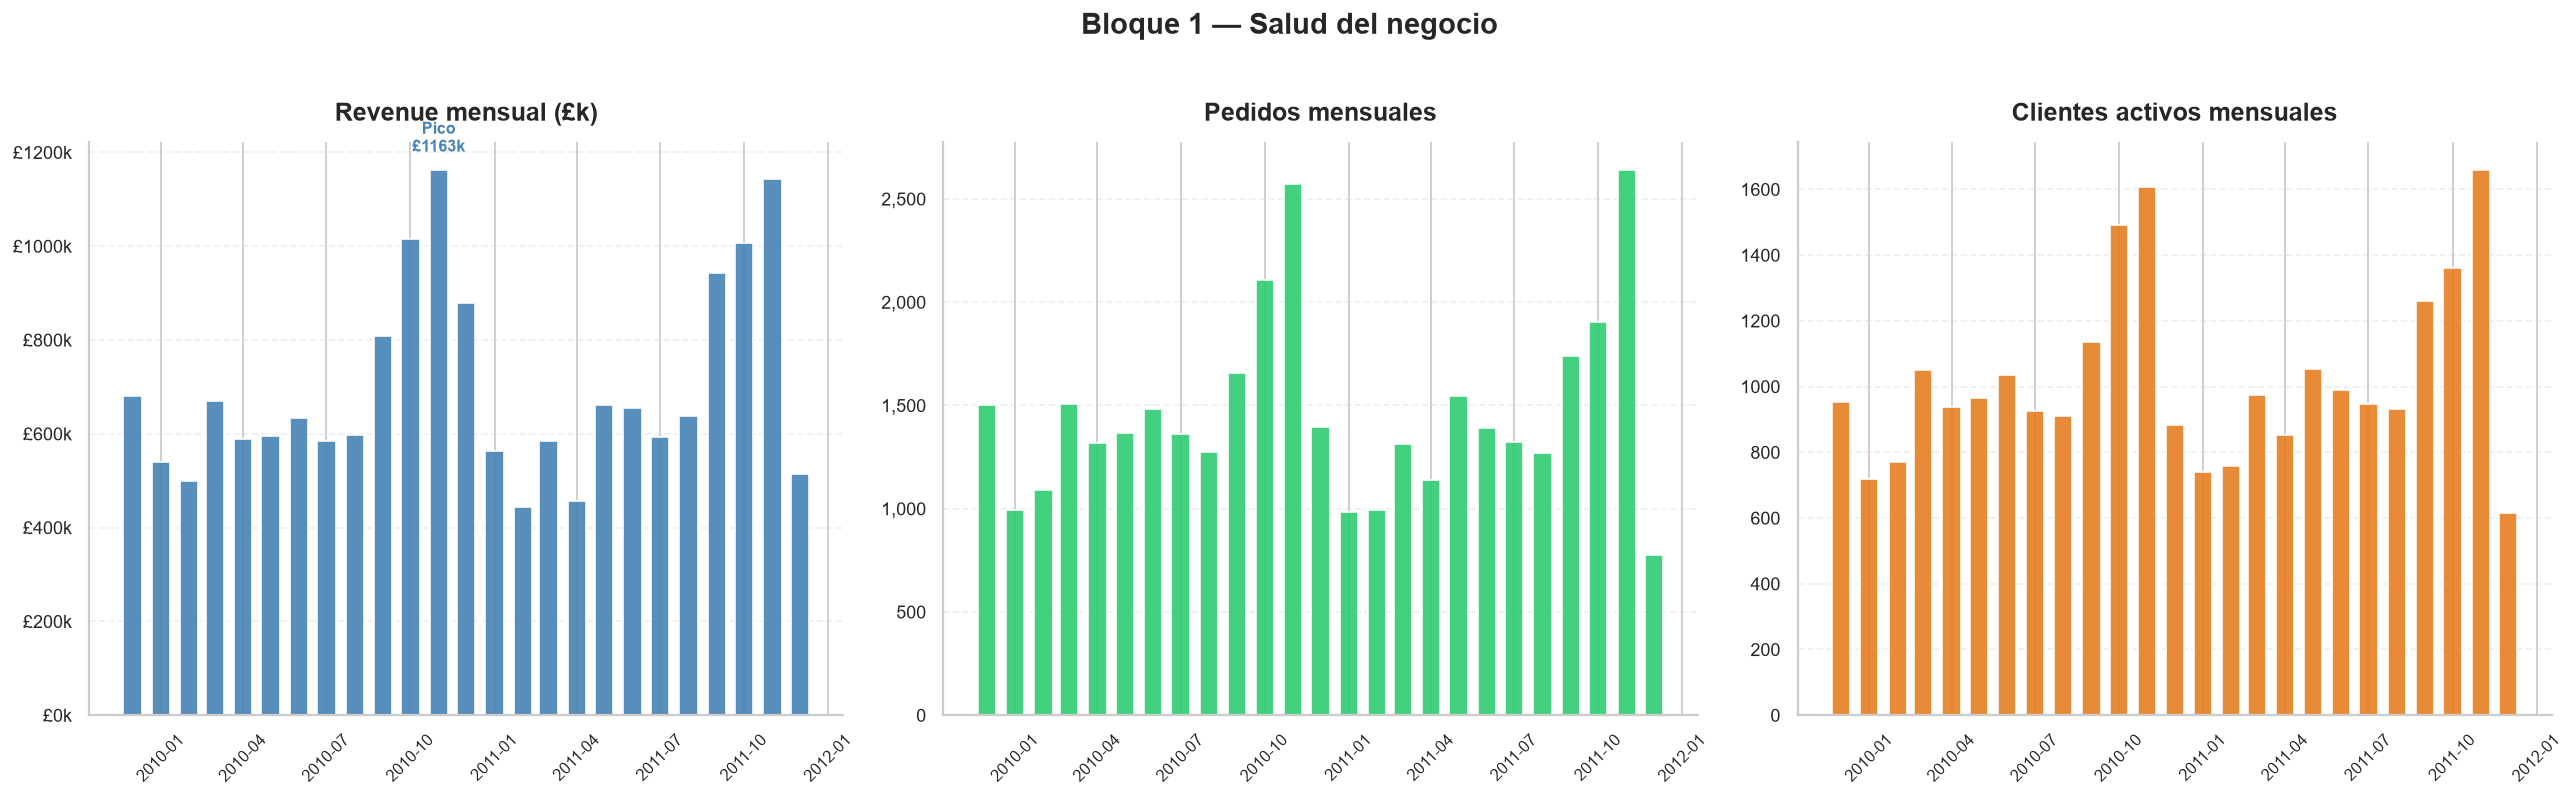


=== KPIs GENERALES ===
Revenue total:          £17,451,756
Ticket medio por orden: £476.24
Revenue medio mensual:  £698,070
Mes pico de revenue:    2010-11


In [4]:
# ── Revenue mensual ──────────────────────────────────────────
monthly = (df.groupby('YearMonth')
             .agg(Revenue=('Revenue', 'sum'),
                  Orders=('Invoice', 'nunique'),
                  Customers=('Customer ID', 'nunique'))
             .reset_index())
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=130)

# — Revenue —
bars0 = axes[0].bar(monthly['YearMonth_dt'], monthly['Revenue']/1000,
                     color='steelblue', alpha=0.9, width=20)
axes[0].set_title('Revenue mensual (£k)', fontsize=14, fontweight='bold', pad=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', labelsize=10)
# Etiqueta en el bar más alto
max_idx = monthly['Revenue'].idxmax()
axes[0].annotate(f"Pico\n£{monthly['Revenue'].iloc[max_idx]/1000:.0f}k",
                 xy=(monthly['YearMonth_dt'].iloc[max_idx], monthly['Revenue'].iloc[max_idx]/1000),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color='steelblue', fontweight='bold')

# — Pedidos —
axes[1].bar(monthly['YearMonth_dt'], monthly['Orders'],
            color='#2ECC71', alpha=0.9, width=20)
axes[1].set_title('Pedidos mensuales', fontsize=14, fontweight='bold', pad=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# — Clientes activos —
axes[2].bar(monthly['YearMonth_dt'], monthly['Customers'],
            color='#E67E22', alpha=0.9, width=20)
axes[2].set_title('Clientes activos mensuales', fontsize=14, fontweight='bold', pad=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', labelsize=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Bloque 1 — Salud del negocio', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== KPIs GENERALES ===")
print(f"Revenue total:          £{df['Revenue'].sum():,.0f}")
print(f"Ticket medio por orden: £{df.groupby('Invoice')['Revenue'].sum().mean():,.2f}")
print(f"Revenue medio mensual:  £{monthly['Revenue'].mean():,.0f}")
print(f"Mes pico de revenue:    {monthly.loc[monthly['Revenue'].idxmax(), 'YearMonth']}")

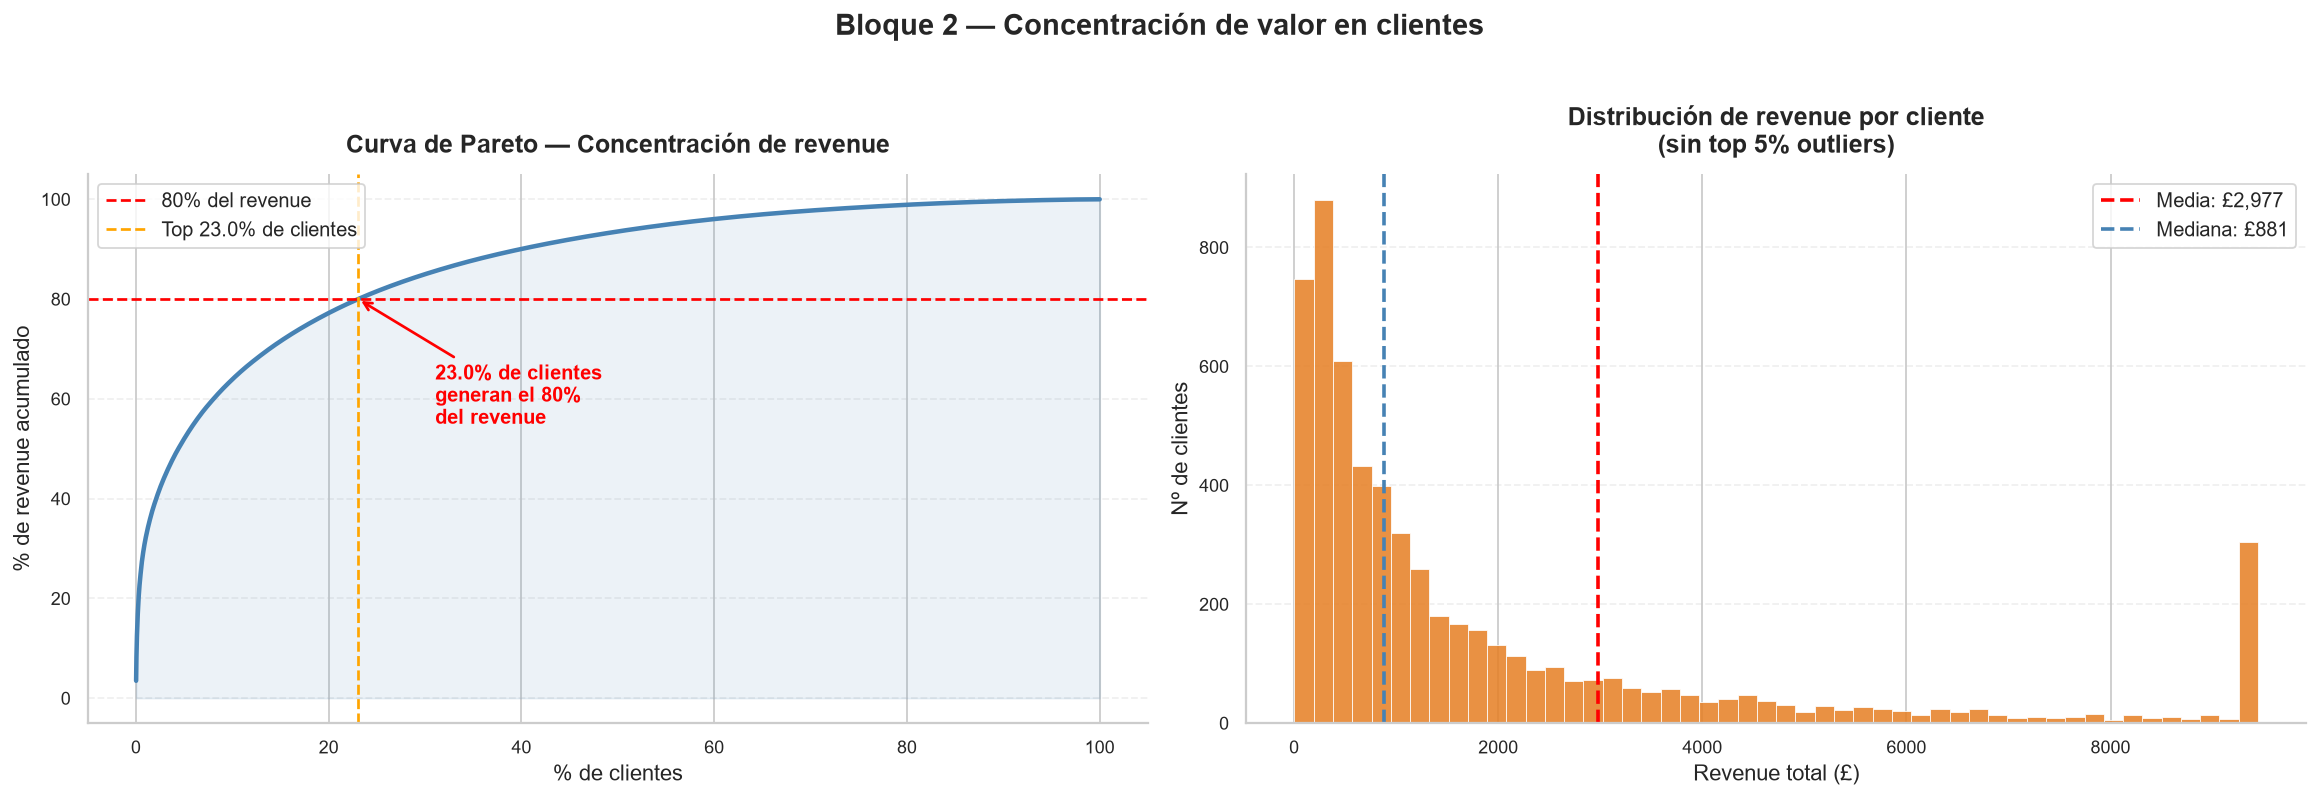


=== ANÁLISIS DE PARETO ===
El 23.0% de clientes genera el 80% del revenue
Revenue medio por cliente:   £2,977
Revenue mediano por cliente: £881
Cliente top 1:               £608,822


In [6]:
customer_revenue = (df.groupby('Customer ID')['Revenue']
                      .sum()
                      .sort_values(ascending=False)
                      .reset_index())
customer_revenue['cumulative_pct'] = (customer_revenue['Revenue'].cumsum() 
                                       / customer_revenue['Revenue'].sum() * 100)
customer_revenue['customer_pct'] = (np.arange(1, len(customer_revenue)+1) 
                                     / len(customer_revenue) * 100)

top80 = customer_revenue[customer_revenue['cumulative_pct'] <= 80]
pct_clients_80 = len(top80) / len(customer_revenue) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=130)

# — Curva de Pareto —
axes[0].plot(customer_revenue['customer_pct'], 
             customer_revenue['cumulative_pct'], 
             color='steelblue', linewidth=2.5)
axes[0].fill_between(customer_revenue['customer_pct'],
                     customer_revenue['cumulative_pct'],
                     alpha=0.1, color='steelblue')
axes[0].axhline(80, color='red', linestyle='--', linewidth=1.5,
                label='80% del revenue')
axes[0].axvline(pct_clients_80, color='orange', linestyle='--', linewidth=1.5,
                label=f'Top {pct_clients_80:.1f}% de clientes')
axes[0].annotate(f'{pct_clients_80:.1f}% de clientes\ngeneran el 80%\ndel revenue',
                 xy=(pct_clients_80, 80),
                 xytext=(pct_clients_80 + 8, 55),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
axes[0].set_xlabel('% de clientes', fontsize=12)
axes[0].set_ylabel('% de revenue acumulado', fontsize=12)
axes[0].set_title('Curva de Pareto — Concentración de revenue', 
                  fontsize=14, fontweight='bold', pad=12)
axes[0].legend(fontsize=11)
axes[0].tick_params(labelsize=10)

# — Distribución de revenue —
p95 = customer_revenue['Revenue'].quantile(0.95)
axes[1].hist(customer_revenue['Revenue'].clip(upper=p95),
             bins=50, color='#E67E22', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].axvline(customer_revenue['Revenue'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Media: £{customer_revenue['Revenue'].mean():,.0f}")
axes[1].axvline(customer_revenue['Revenue'].median(), color='steelblue', 
                linestyle='--', linewidth=2, label=f"Mediana: £{customer_revenue['Revenue'].median():,.0f}")
axes[1].set_title('Distribución de revenue por cliente\n(sin top 5% outliers)', 
                  fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Revenue total (£)', fontsize=12)
axes[1].set_ylabel('Nº de clientes', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].tick_params(labelsize=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Bloque 2 — Concentración de valor en clientes', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n=== ANÁLISIS DE PARETO ===")
print(f"El {pct_clients_80:.1f}% de clientes genera el 80% del revenue")
print(f"Revenue medio por cliente:   £{customer_revenue['Revenue'].mean():,.0f}")
print(f"Revenue mediano por cliente: £{customer_revenue['Revenue'].median():,.0f}")
print(f"Cliente top 1:               £{customer_revenue['Revenue'].iloc[0]:,.0f}")

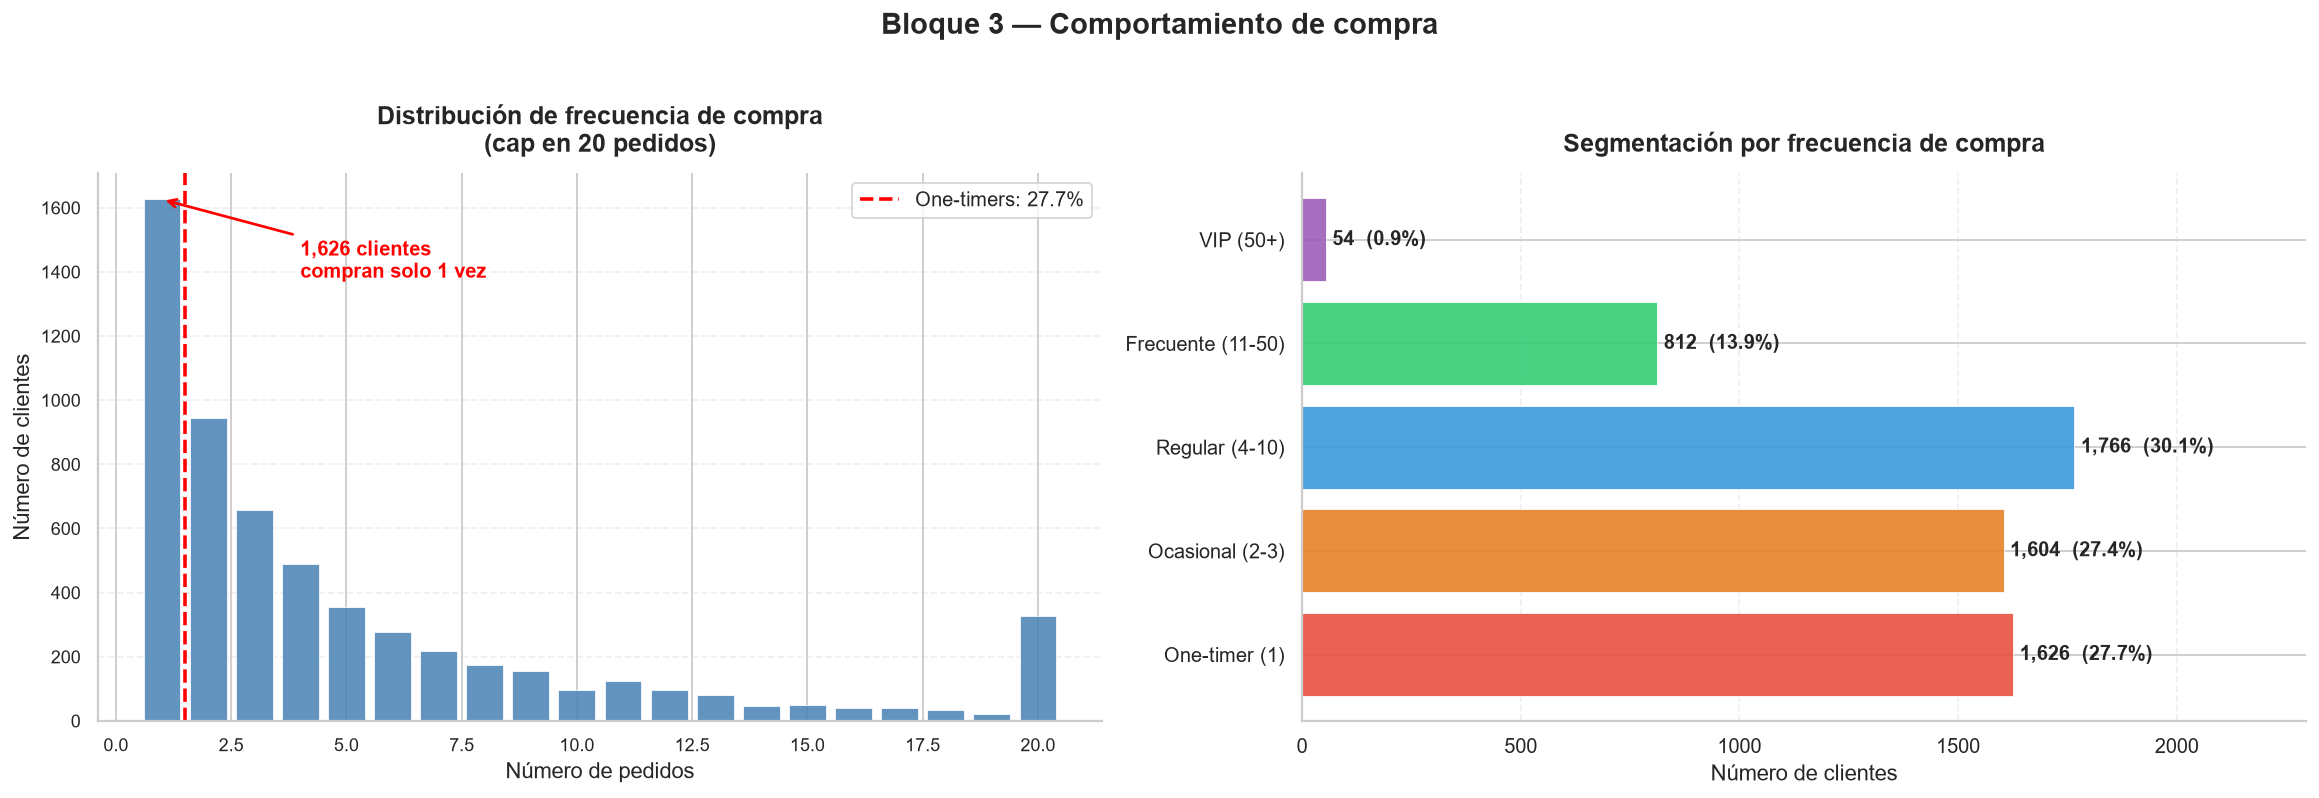


=== ONE-TIMERS ===
Clientes que compraron solo 1 vez:  1,626 (27.7%)
Clientes recurrentes (2+ compras):  4,236 (72.3%)

Segmentación completa:
  One-timer (1)          1,626  (27.7%)
  Ocasional (2-3)        1,604  (27.4%)
  Regular (4-10)         1,766  (30.1%)
  Frecuente (11-50)        812  (13.9%)
  VIP (50+)                 54  (0.9%)


In [7]:
purchase_freq = (df.groupby('Customer ID')['Invoice']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Invoice': 'num_orders'}))

one_timers = (purchase_freq['num_orders'] == 1).sum()
one_timer_pct = one_timers / len(purchase_freq) * 100

freq_dist = purchase_freq['num_orders'].clip(upper=20).value_counts().sort_index()

freq_segments = pd.cut(purchase_freq['num_orders'], 
                        bins=[0,1,3,10,50,999],
                        labels=['One-timer (1)', 'Ocasional (2-3)', 
                                'Regular (4-10)', 'Frecuente (11-50)', 'VIP (50+)'])
seg_counts = freq_segments.value_counts().sort_index()
seg_colors = ['#E74C3C','#E67E22','#3498DB','#2ECC71','#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=130)

# — Distribución frecuencia —
axes[0].bar(freq_dist.index, freq_dist.values, color='steelblue', alpha=0.85, 
            edgecolor='white', linewidth=0.5)
axes[0].axvline(1.5, color='red', linestyle='--', linewidth=2,
                label=f'One-timers: {one_timer_pct:.1f}%')
axes[0].set_title('Distribución de frecuencia de compra\n(cap en 20 pedidos)', 
                  fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Número de pedidos', fontsize=12)
axes[0].set_ylabel('Número de clientes', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].tick_params(labelsize=10)
axes[0].annotate(f'{one_timers:,} clientes\ncompran solo 1 vez',
                 xy=(1, freq_dist.iloc[0]),
                 xytext=(4, freq_dist.iloc[0] * 0.85),
                 fontsize=11, fontweight='bold', color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# — Segmentación —
bars = axes[1].barh(seg_counts.index.astype(str), seg_counts.values,
                    color=seg_colors, alpha=0.88, edgecolor='white', linewidth=0.5)
axes[1].set_title('Segmentación por frecuencia de compra', 
                  fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Número de clientes', fontsize=12)
axes[1].tick_params(labelsize=11)
for i, v in enumerate(seg_counts.values):
    axes[1].text(v + 15, i, f'{v:,}  ({v/len(purchase_freq)*100:.1f}%)', 
                 va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, seg_counts.max() * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x' if ax == axes[1] else 'y', alpha=0.3, linestyle='--')

plt.suptitle('Bloque 3 — Comportamiento de compra', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n=== ONE-TIMERS ===")
print(f"Clientes que compraron solo 1 vez:  {one_timers:,} ({one_timer_pct:.1f}%)")
print(f"Clientes recurrentes (2+ compras):  {len(purchase_freq)-one_timers:,} ({100-one_timer_pct:.1f}%)")
print(f"\nSegmentación completa:")
for seg, count in seg_counts.items():
    print(f"  {str(seg):<22} {count:>5,}  ({count/len(purchase_freq)*100:.1f}%)")

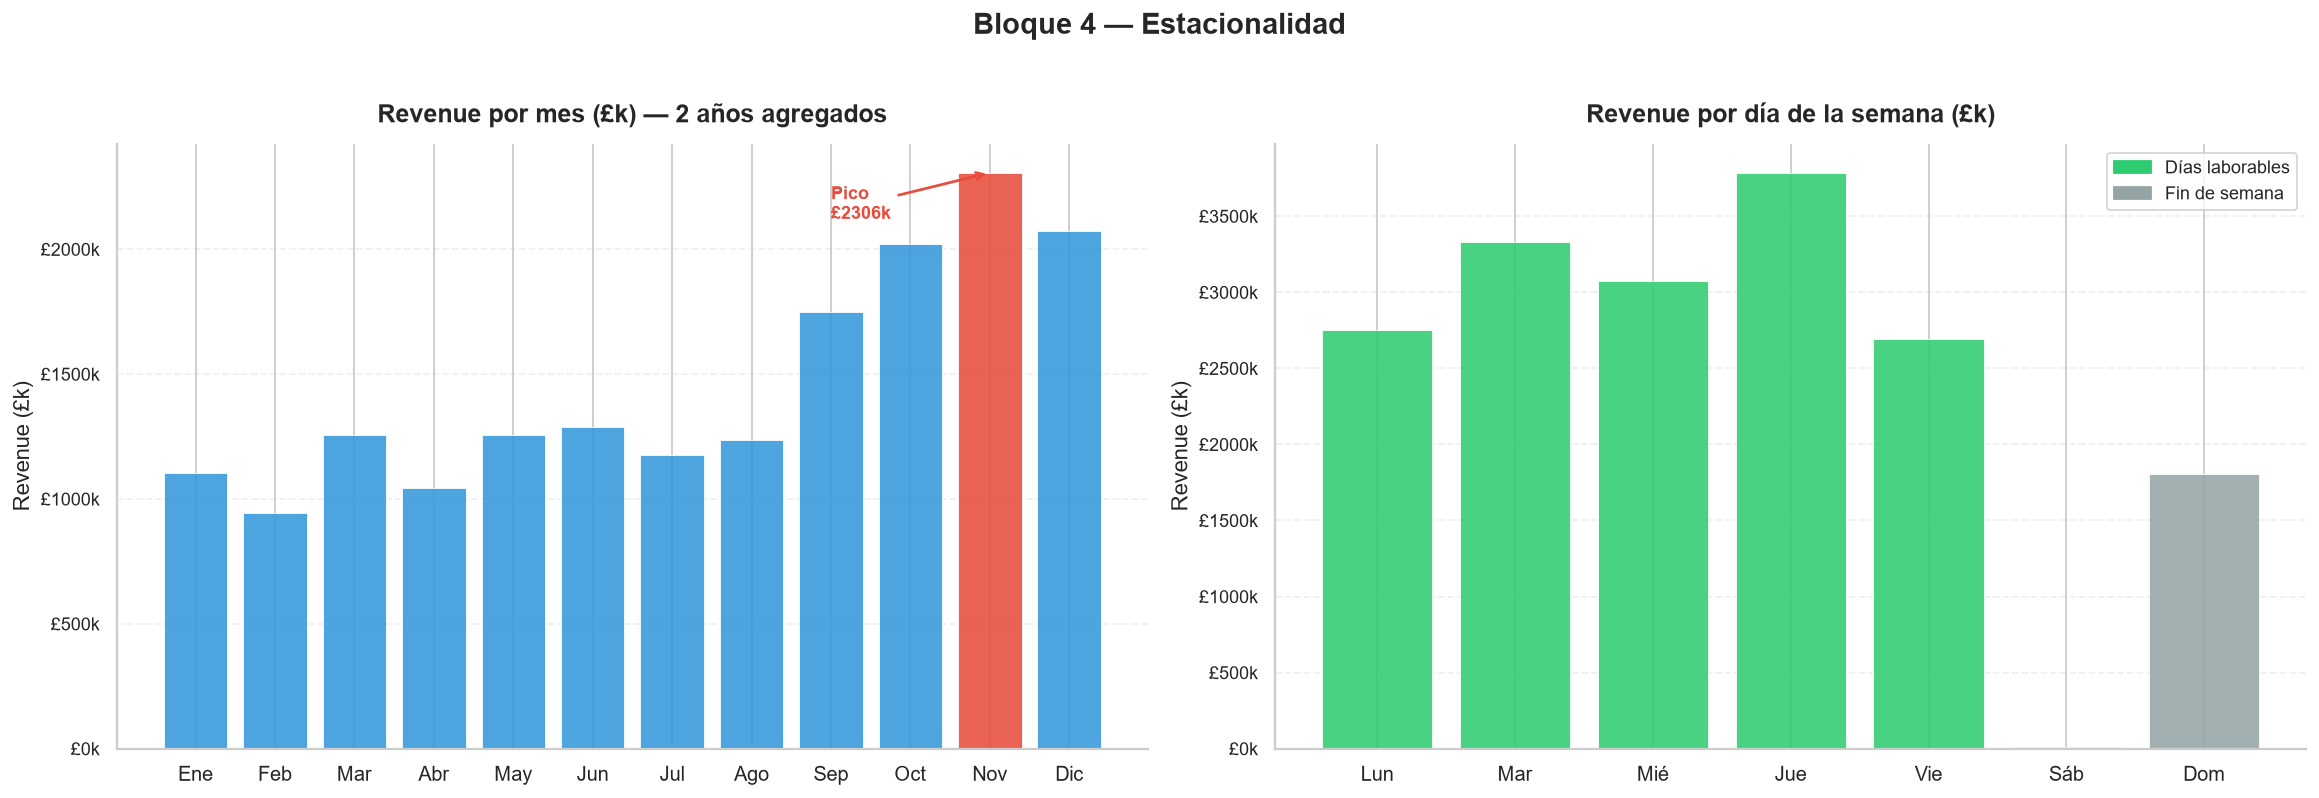


=== ESTACIONALIDAD ===
Mes de mayor revenue: Nov (£2,306,400)
Mes de menor revenue: Feb (£943,496)
Ratio pico/valle:     2.4x
Día de mayor revenue: Thursday (£3,785,821)
Domingo vs Jueves:    £1,805,947 vs £3,785,821


In [8]:
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

month_rev = df.groupby('Month')['Revenue'].sum()
month_names = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
dow_labels = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=130)

# — Revenue por mes —
colors_month = ['#3498DB' if v < month_rev.max() * 0.9 else '#E74C3C' 
                for v in month_rev.values]
bars = axes[0].bar(range(1,13), month_rev.values/1000, 
                   color=colors_month, alpha=0.88, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, fontsize=11)
axes[0].set_title('Revenue por mes (£k) — 2 años agregados', 
                  fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Revenue (£k)', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
axes[0].tick_params(axis='y', labelsize=10)
# Etiqueta pico
max_m = month_rev.idxmax()
axes[0].annotate(f'Pico\n£{month_rev[max_m]/1000:.0f}k',
                 xy=(max_m, month_rev[max_m]/1000),
                 xytext=(max_m - 2, month_rev[max_m]/1000 * 0.92),
                 fontsize=10, fontweight='bold', color='#E74C3C',
                 arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# — Revenue por día —
colors_dow = ['#2ECC71' if d not in ['Saturday','Sunday'] else '#95A5A6' 
              for d in dow_order]
axes[1].bar(range(7), dow_rev.values/1000, color=colors_dow, 
            alpha=0.88, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels, fontsize=11)
axes[1].set_title('Revenue por día de la semana (£k)', 
                  fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Revenue (£k)', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
axes[1].tick_params(axis='y', labelsize=10)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2ECC71', label='Días laborables'),
                         Patch(color='#95A5A6', label='Fin de semana')],
               fontsize=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Bloque 4 — Estacionalidad', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== ESTACIONALIDAD ===")
print(f"Mes de mayor revenue: {month_names[month_rev.idxmax()-1]} (£{month_rev.max():,.0f})")
print(f"Mes de menor revenue: {month_names[month_rev.idxmin()-1]} (£{month_rev.min():,.0f})")
print(f"Ratio pico/valle:     {month_rev.max()/month_rev.min():.1f}x")
print(f"Día de mayor revenue: {dow_rev.idxmax()} (£{dow_rev.max():,.0f})")
print(f"Domingo vs Jueves:    £{dow_rev['Sunday']:,.0f} vs £{dow_rev['Thursday']:,.0f}")

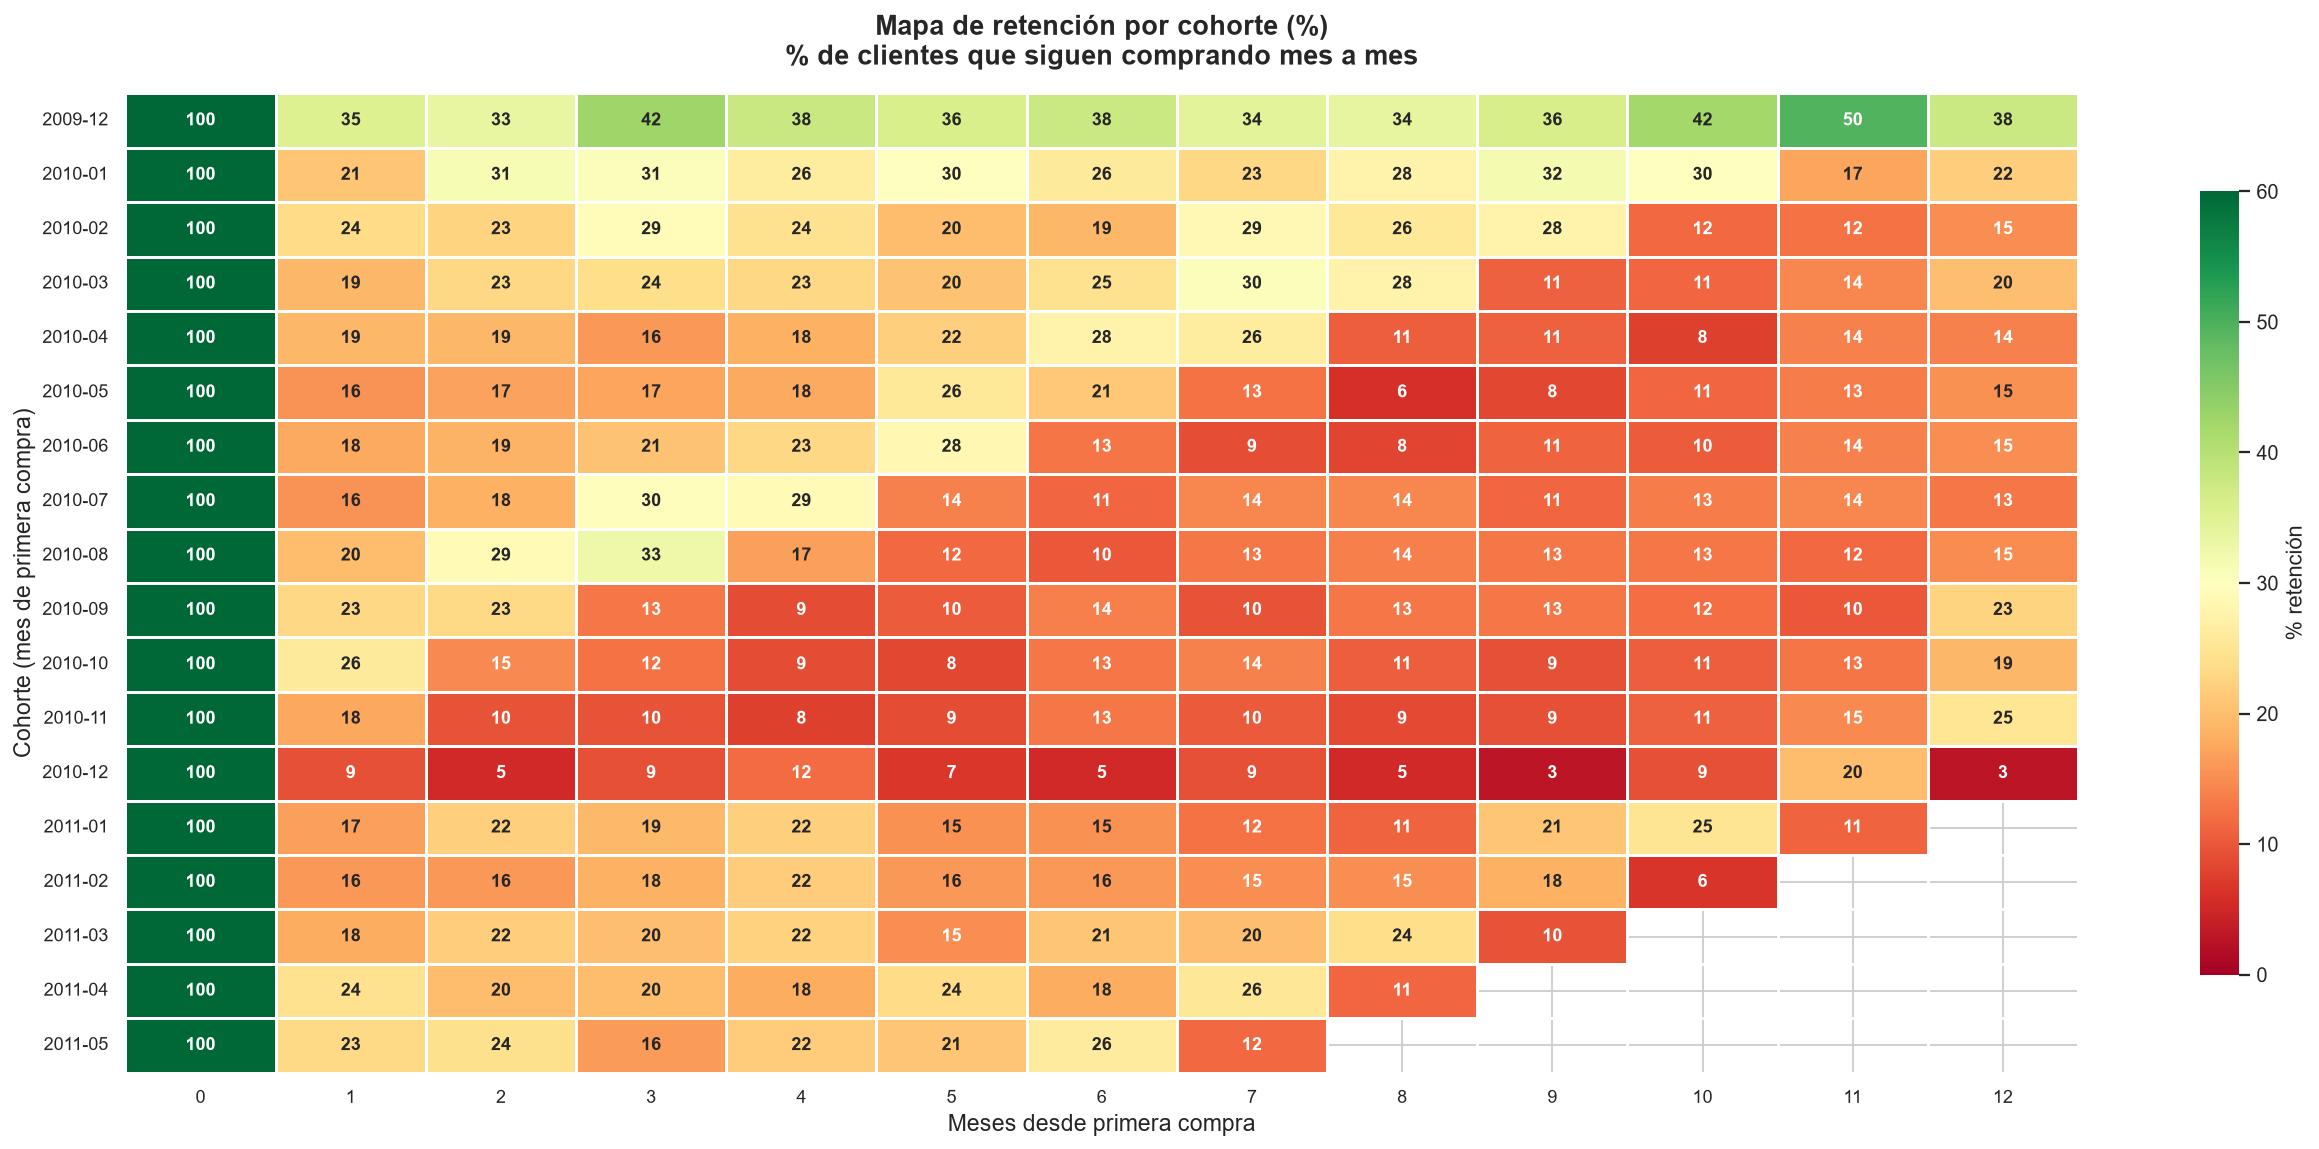


=== RETENCIÓN MEDIA POR MES ===
Mes  1:  21.0%  ██████████
Mes  2:  21.9%  ██████████
Mes  3:  21.7%  ██████████
Mes  6:  17.9%  ████████
Mes 12:  18.2%  █████████

=== REVENUE EN RIESGO ===
Revenue medio por cliente:     £2,977
One-timers recuperables (est): 813 clientes
Revenue potencial recuperable: £2,420,382

→ Este es el problema de negocio que resuelve el modelo ML


In [9]:
df['CohortMonth'] = (df.groupby('Customer ID')['InvoiceDate']
                       .transform('min')
                       .dt.to_period('M'))
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortIndex'] = ((df['OrderMonth'] - df['CohortMonth'])
                     .apply(lambda x: x.n))

cohort_data = (df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
                 .nunique()
                 .reset_index())
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', 
                                        columns='CohortIndex', 
                                        values='Customer ID')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(20, 9), dpi=130)
sns.heatmap(retention.iloc[:18, :13],
            annot=True, fmt='.0f',
            cmap='RdYlGn',
            linewidths=0.8,
            linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax,
            vmin=0, vmax=60,
            cbar_kws={'label': '% retención', 'shrink': 0.8})
ax.set_title('Mapa de retención por cohorte (%)\n% de clientes que siguen comprando mes a mes', 
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Meses desde primera compra', fontsize=13)
ax.set_ylabel('Cohorte (mes de primera compra)', fontsize=13)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

print("\n=== RETENCIÓN MEDIA POR MES ===")
for m in [1, 2, 3, 6, 12]:
    if m in retention.columns:
        val = retention[m].mean()
        bar = '█' * int(val / 2)
        print(f"Mes {m:2d}: {val:5.1f}%  {bar}")

print(f"\n=== REVENUE EN RIESGO ===")
avg_customer_revenue = df.groupby('Customer ID')['Revenue'].sum().mean()
churned_estimate = int(one_timers * 0.5)
print(f"Revenue medio por cliente:     £{avg_customer_revenue:,.0f}")
print(f"One-timers recuperables (est): {churned_estimate:,} clientes")
print(f"Revenue potencial recuperable: £{churned_estimate * avg_customer_revenue:,.0f}")
print(f"\n→ Este es el problema de negocio que resuelve el modelo ML")

## Conclusiones del EDA

El análisis exploratorio sobre 802.949 transacciones de 5.862 clientes 
entre diciembre 2009 y diciembre 2011 revela tres problemas de negocio 
accionables.

### Lo que encontramos

El negocio genera £17.4M en dos años con un ticket medio de £476, 
pero el crecimiento está muy concentrado. Solo el 23% de clientes 
genera el 80% del revenue, y la diferencia entre la media (£2.977) 
y la mediana (£881) por cliente indica una base muy polarizada.

La retención es el problema central. De cada 100 clientes nuevos, 
solo 21 vuelven a comprar el mes siguiente, y esa tasa se estabiliza 
entre el 18% y el 22% a lo largo de los 12 meses siguientes. 
El 27.7% de clientes (1.626 personas) ha comprado una única vez 
y no ha vuelto.

La estacionalidad añade presión adicional: el revenue de noviembre 
es 2.4 veces superior al de febrero, lo que significa que las 
decisiones de inversión en marketing no pueden ser uniformes a 
lo largo del año.

### El problema de negocio que queremos resolver

Si el revenue medio por cliente es de £2.977 y hay 813 one-timers 
potencialmente recuperables, el impacto económico estimado de 
recuperar la mitad de ellos es de £2.4M.

La pregunta no es cuánto vale cada cliente.  
La pregunta es: dado un presupuesto limitado de marketing, 
¿en qué clientes merece la pena invertir?

### Qué construiremos a continuación

Para responder esa pregunta necesitamos tres cosas:
segmentar a los clientes por comportamiento real,
predecir quién tiene mayor probabilidad de volver a comprar,
y estimar cuánto valor generaría esa recompra.

Con esos tres elementos podremos construir un sistema que asigne 
el presupuesto de marketing donde el retorno esperado es mayor.